In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

os.makedirs('outputs', exist_ok=True)

## EDA(Exploratory Data Analysis)

## Feature Engineering

Date Based Features

In [4]:
# ensure datetime
data=pd.read_csv(r'C:\Users\dell\Desktop\hotel-booking-analysis\cleaned_data\hotel_bookings_cleaned.csv')
date_cols = ['booking_date', 'check_in_date', 'check_out_date']
for col in date_cols:
    data[col] = pd.to_datetime(data[col], errors='coerce')

# booking month
data['booking_month'] = data['booking_date'].dt.month

# check-in month (seasonality)
data['checkin_month'] = data['check_in_date'].dt.month

# day of week
data['booking_day'] = data['booking_date'].dt.day_name()

Stay & Lead Time

In [5]:
# total stay duration
data['total_nights'] = (data['check_out_date'] - data['check_in_date']).dt.days

# lead time (how early booking is made)
data['lead_time'] = (data['check_in_date'] - data['booking_date']).dt.days

Pricing & Discount Features

In [6]:
# effective price after discounts
data['effective_price'] = data['selling_price'] - data['cashback'] - data['coupon_redeem']

# discount amount
data['total_discount'] = data['cashback'] + data['coupon_redeem']

In [8]:
data.columns

Index(['customer_id', 'property_id', 'city', 'star_rating', 'booking_date',
       'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked',
       'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup',
       'selling_price', 'payment_method', 'refund_status', 'refund_amount',
       'channel_of_booking', 'booking_status', 'travel_date', 'cashback',
       'coupon_redeem', 'Coupon USed?', 'is_refunded', 'is_cancelled',
       'booking_month', 'checkin_month', 'booking_day', 'total_nights',
       'lead_time', 'effective_price', 'total_discount'],
      dtype='str')

In [9]:
data[['total_nights', 'lead_time']].describe()

,total_nights,lead_time
count,24532.000000,24532.000000
mean,4.006848,30.378485
std,2.001231,17.374172
min,1.000000,1.000000
25%,2.000000,15.000000
50%,4.000000,30.000000
75%,6.000000,45.000000
max,7.000000,60.000000


In [10]:
data[['total_nights', 'lead_time']].describe()

,total_nights,lead_time
count,24532.000000,24532.000000
mean,4.006848,30.378485
std,2.001231,17.374172
min,1.000000,1.000000
25%,2.000000,15.000000
50%,4.000000,30.000000
75%,6.000000,45.000000
max,7.000000,60.000000


In [11]:
data[['selling_price', 'total_discount', 'effective_price']].head()

,selling_price,total_discount,effective_price
0,25342,5.374694,25336.625306
1,8033,7.161033,8025.838967
2,29715,0.000000,29715.000000
3,44592,32.432612,44559.567388
4,15873,0.000000,15873.000000


## Data Analysis

In [14]:
data['booking_channel'].value_counts(normalize=True)*100


booking_channel
Web             50.003333
Mobile App      40.030000
Travel Agent     9.966667
Name: proportion, dtype: float64

Most bookings are made through the web platform (around 50%), followed by the mobile app (~40%), while travel agents contribute a smaller share (~10%)

In [15]:
data['room_type'].value_counts(normalize=True)*100

room_type
Standard    55.173333
Deluxe      34.926667
Suite        9.900000
Name: proportion, dtype: float64

Standard rooms dominate bookings (~55%), indicating high price sensitivity among customers. Deluxe rooms account for ~35%, showing a good segment willing to pay for better comfort, while Suites (~10%) represent a niche premium segment

In [16]:
data['star_rating'].value_counts(normalize=True)*100

star_rating
4    40.113333
3    34.866667
5    15.036667
2     9.983333
Name: proportion, dtype: float64

Most bookings are concentrated in mid-range hotels, with 4-star properties leading (~40%), followed by 3-star (~35%). This shows a strong preference for value-for-money options. Premium 5-star hotels contribute ~15%, while budget 2-star hotels have the lowest share (~10%).”


Recomendations:
1. Focus on web/app channels and mid-range hotels (3–4 star with standard rooms) as they drive most bookings
2. Use better UX and smart upselling (Standard → Deluxe) to increase revenue
3. Offer targeted discounts for low-demand segments while keeping premium options high-priced

1. Monthly Booking Trend

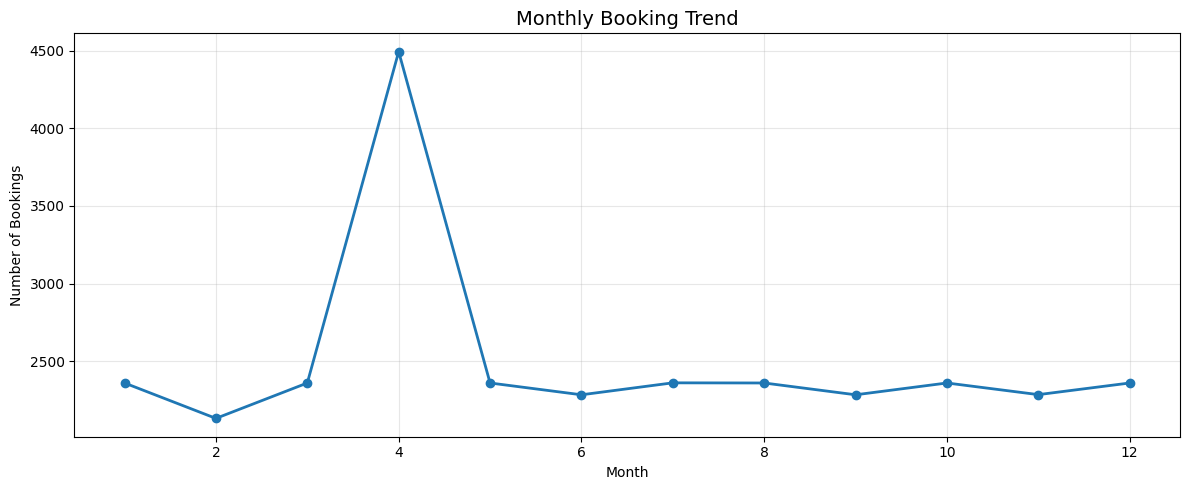

In [66]:
import matplotlib.pyplot as plt

monthly_bookings = data.groupby('booking_month').size()

plt.figure(figsize=(12,5))  # wider plot

plt.plot(monthly_bookings.index, monthly_bookings.values,
         marker='o', linewidth=2)

plt.title('Monthly Booking Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Bookings')

plt.grid(alpha=0.3)  
plt.tight_layout()   
plt.savefig('outputs/Monthly_Booking_Trend.png', dpi=300, bbox_inches='tight')
plt.show()


In [20]:
data['selling_price'].value_counts

<bound method IndexOpsMixin.value_counts of 0        25342
1         8033
2        29715
3        44592
4        15873
         ...  
29995    23365
29996    22047
29997    26321
29998    20806
29999    27518
Name: selling_price, Length: 30000, dtype: int64>

2. Monthly Revenue Trend

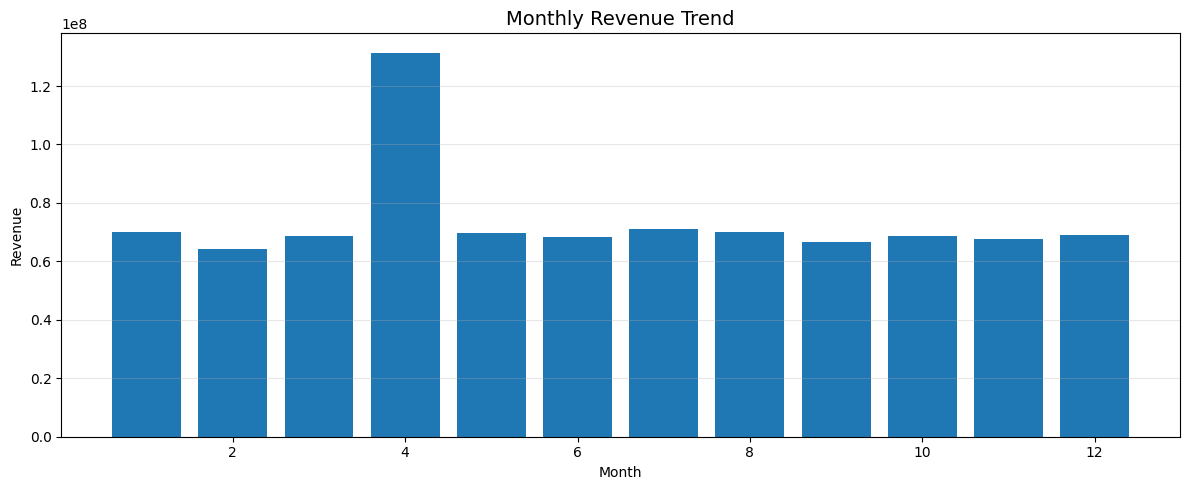

In [67]:
import matplotlib.pyplot as plt

monthly_revenue = data.groupby('booking_month')['selling_price'].sum()

plt.figure(figsize=(12,5))

plt.bar(monthly_revenue.index, monthly_revenue.values)

plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(axis='y', alpha=0.3)  # only horizontal grid
plt.tight_layout()

plt.savefig('outputs/Monthly_Revenue_Trend.png', dpi=300, bbox_inches='tight')
plt.show()


3. Cancellation Trend Over Time

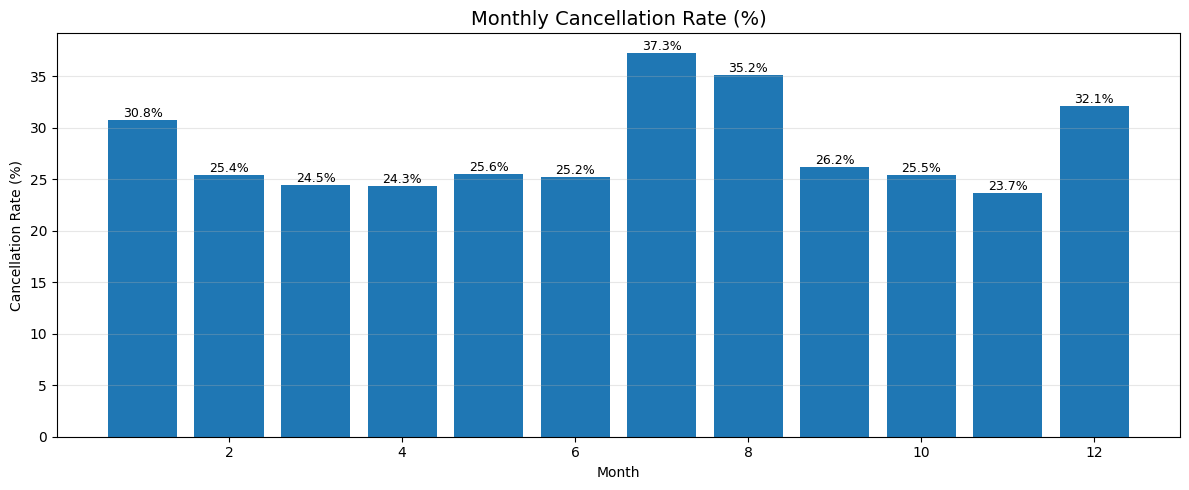

In [68]:
import matplotlib.pyplot as plt

monthly_cancellation = data.groupby('booking_month')['is_cancelled'].mean() * 100

plt.figure(figsize=(12,5))

bars = plt.bar(monthly_cancellation.index, monthly_cancellation.values)

# Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('Monthly Cancellation Rate (%)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/Monthly_Cancellation_Rate.png', dpi=300, bbox_inches='tight')
plt.show()


4. Booking channel vs room type

<Figure size 1200x600 with 0 Axes>

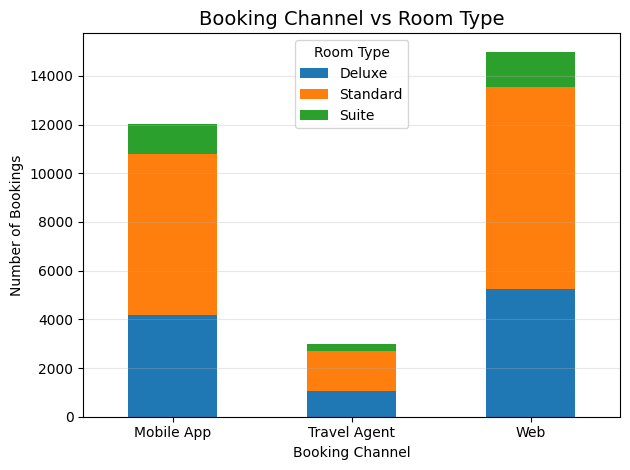

In [69]:
import matplotlib.pyplot as plt

channel_room = pd.crosstab(data['booking_channel'], data['room_type'])

plt.figure(figsize=(12,6))

channel_room.plot(kind='bar', stacked=True)

plt.title('Booking Channel vs Room Type', fontsize=14)
plt.xlabel('Booking Channel')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=0)
plt.legend(title='Room Type')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/Booking_Channel vs Room_Type.png', dpi=300, bbox_inches='tight')
plt.show()


5. Booking channel vs star ratings 

<Figure size 1200x600 with 0 Axes>

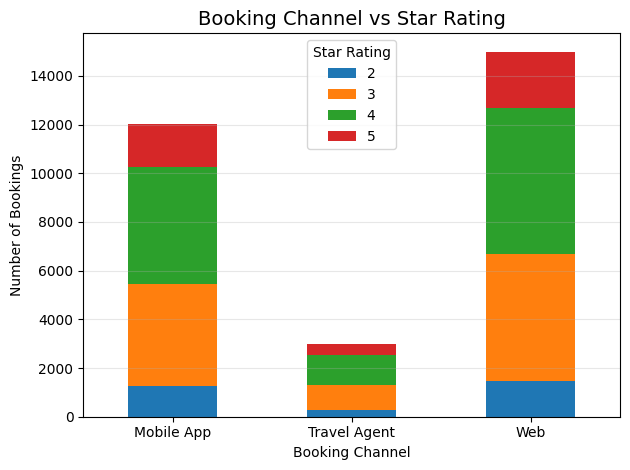

In [75]:
import matplotlib.pyplot as plt

channel_star = pd.crosstab(data['booking_channel'], data['star_rating'])

plt.figure(figsize=(12,6))

channel_star.plot(kind='bar', stacked=True)

plt.title('Booking Channel vs Star Rating', fontsize=14)
plt.xlabel('Booking Channel')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=0)
plt.legend(title='Star Rating')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/Booking_Channel vs Star_Rating .png', dpi=300, bbox_inches='tight')
plt.show()


6. Room type vs cancellation rate 

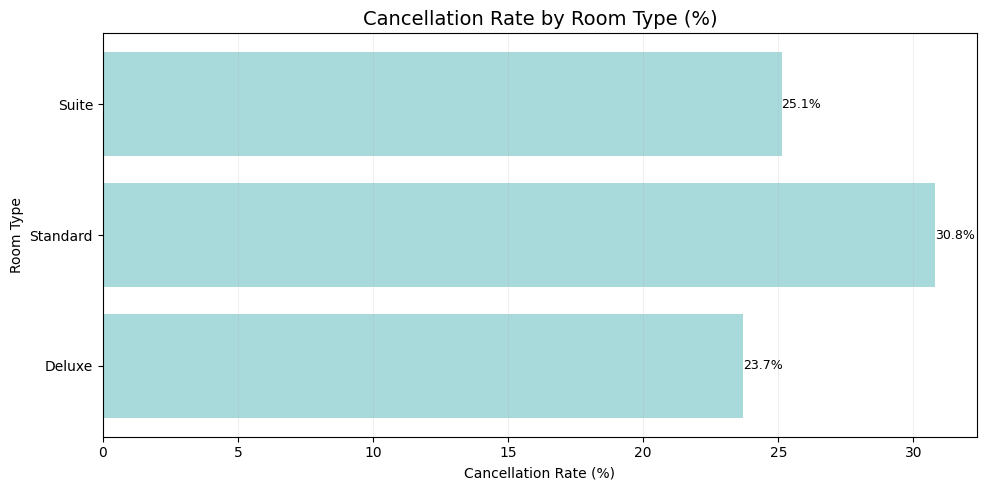

In [71]:
import matplotlib.pyplot as plt

room_cancel = data.groupby('room_type')['is_cancelled'].mean() * 100

plt.figure(figsize=(10,5))

bars = plt.barh(room_cancel.index, room_cancel.values,
                color='#a8dadc')  

# Add percentage labels
for bar in bars:
    xval = bar.get_width()
    plt.text(xval, bar.get_y() + bar.get_height()/2,
             f'{xval:.1f}%', va='center', fontsize=9)

plt.title('Cancellation Rate by Room Type (%)', fontsize=14)
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Room Type')

plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('outputs/Cancellation_Rate_by_RoomType', dpi=300, bbox_inches='tight')
plt.show()


7. Channel vs cancellation rate

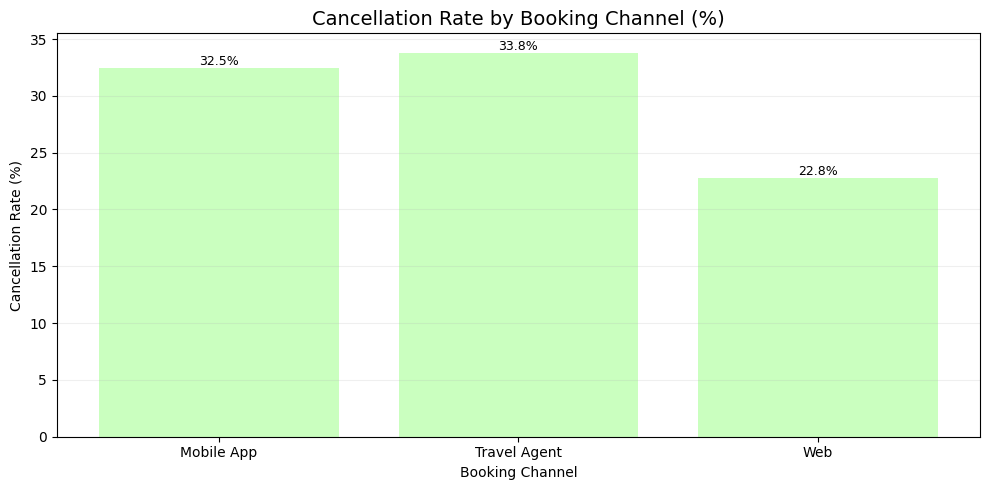

In [72]:
import matplotlib.pyplot as plt

channel_cancel = data.groupby('booking_channel')['is_cancelled'].mean() * 100

plt.figure(figsize=(10,5))

bars = plt.bar(channel_cancel.index, channel_cancel.values,
               color='#caffbf')  

# Add percentage labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:.1f}%', ha='center', va='bottom', fontsize=9)

plt.title('Cancellation Rate by Booking Channel (%)', fontsize=14)
plt.xlabel('Booking Channel')
plt.ylabel('Cancellation Rate (%)')

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('outputs/Cancellation_Rate_by_BookingChannel.png', dpi=300, bbox_inches='tight')
plt.show()


Key Observations:

1. Bookings and revenue exhibit a clear peak in April, indicating strong seasonal demand, followed by a stable trend across the remaining months.

2. The alignment between bookings and revenue suggests consistent pricing and demand patterns throughout the year.

3. Cancellation rates show notable variability, with a sharp increase in July (~37%) and August (~35%), compared to other months averaging around 24–30%.

4. Web channel dominates bookings across all room types and star categories, followed by Mobile App, while Travel Agents contribute the least.

5. Standard rooms and mid-range hotels (3–4 star) are the most preferred across all booking channels, indicating strong demand for value-for-money options.

6. Cancellation rates are highest for Standard rooms (~31%), compared to Deluxe (~24%) and Suite (~25%), suggesting higher uncertainty in budget segments.

7. Booking channel-wise cancellations show a clear pattern: Travel Agents (~34%) have the highest cancellation rate, followed by Mobile App (~32%), while Web has the lowest (~23%), making it the most reliable channel.

## Root Cause Analysis

1.Why are cancellation happening .

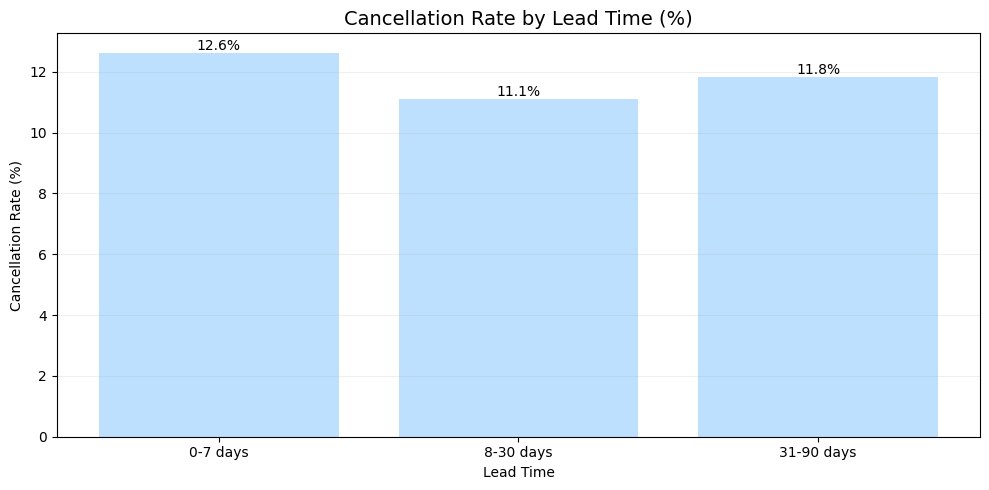

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# Create bins
bins = [0, 7, 30, 90, 180, 365]
labels = ['0-7 days', '8-30 days', '31-90 days', '91-180 days', '180+ days']

data['lead_time_group'] = pd.cut(data['lead_time'], bins=bins, labels=labels)

# Calculate cancellation %
lead_cancel = data.groupby('lead_time_group')['is_cancelled'].mean() * 100

# Plot
plt.figure(figsize=(10,5))

bars = plt.bar(lead_cancel.index, lead_cancel.values, color='#bde0fe')

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval:.1f}%', ha='center', va='bottom')

plt.title('Cancellation Rate by Lead Time (%)', fontsize=14)
plt.xlabel('Lead Time')
plt.ylabel('Cancellation Rate (%)')

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig('outputs/Cancellation_Rate_by_LeadTime.png', dpi=300, bbox_inches='tight')
plt.show()




Cancellations are higher at both extremes very early bookings and last-minute bookings while mid-range bookings are more stable.

2. Why do some channels/property types perform better?

In [37]:
data['booking_channel'].value_counts(normalize=True)*100

booking_channel
Web             50.003333
Mobile App      40.030000
Travel Agent     9.966667
Name: proportion, dtype: float64

In [38]:
data.groupby('booking_channel')['selling_price'].mean()

booking_channel
Mobile App      29422.507120
Travel Agent    29371.013378
Web             29597.382641
Name: selling_price, dtype: float64

In [39]:
data.groupby('booking_channel')['is_cancelled'].mean()

booking_channel
Mobile App      0.324590
Travel Agent    0.338127
Web             0.227918
Name: is_cancelled, dtype: float64

In [40]:
data['star_rating'].value_counts(normalize=True)*100

star_rating
4    40.113333
3    34.866667
5    15.036667
2     9.983333
Name: proportion, dtype: float64

In [41]:
data.groupby('star_rating')['selling_price'].mean()

star_rating
2    29546.662437
3    29649.525048
4    29486.552767
5    29190.222345
Name: selling_price, dtype: float64

In [42]:
data.groupby('star_rating')['is_cancelled'].mean()

star_rating
2    0.271452
3    0.273518
4    0.278877
5    0.287741
Name: is_cancelled, dtype: float64

In [43]:
data['room_type'].value_counts(normalize=True)*100

room_type
Standard    55.173333
Deluxe      34.926667
Suite        9.900000
Name: proportion, dtype: float64

In [44]:
data.groupby('room_type')['selling_price'].mean()

room_type
Deluxe      29370.708723
Standard    29577.740031
Suite       29571.554209
Name: selling_price, dtype: float64

In [45]:
data.groupby('room_type')['is_cancelled'].mean()

room_type
Deluxe      0.236877
Standard    0.308120
Suite       0.251178
Name: is_cancelled, dtype: float64

Some channels performs better than others because performance is driven by a combination of demand, reliability, and customer behavior. Direct channels (especially Web) and mid-range offerings (3–4 star, Deluxe rooms) perform best because they provide the right balance of convenience, trust, and value-for-money. In contrast, budget segments and indirect channels show higher cancellations, indicating lower booking commitment.

In [47]:
data.columns

Index(['customer_id', 'property_id', 'city', 'star_rating', 'booking_date',
       'check_in_date', 'check_out_date', 'room_type', 'num_rooms_booked',
       'stay_type', 'booking_channel', 'booking_value', 'costprice', 'markup',
       'selling_price', 'payment_method', 'refund_status', 'refund_amount',
       'channel_of_booking', 'booking_status', 'travel_date', 'cashback',
       'coupon_redeem', 'Coupon USed?', 'is_refunded', 'is_cancelled',
       'booking_month', 'checkin_month', 'booking_day', 'total_nights',
       'lead_time', 'effective_price', 'total_discount', 'lead_time_group'],
      dtype='str')

3. Are there seasonal or temporal trends influencing booking values or stay lengths?

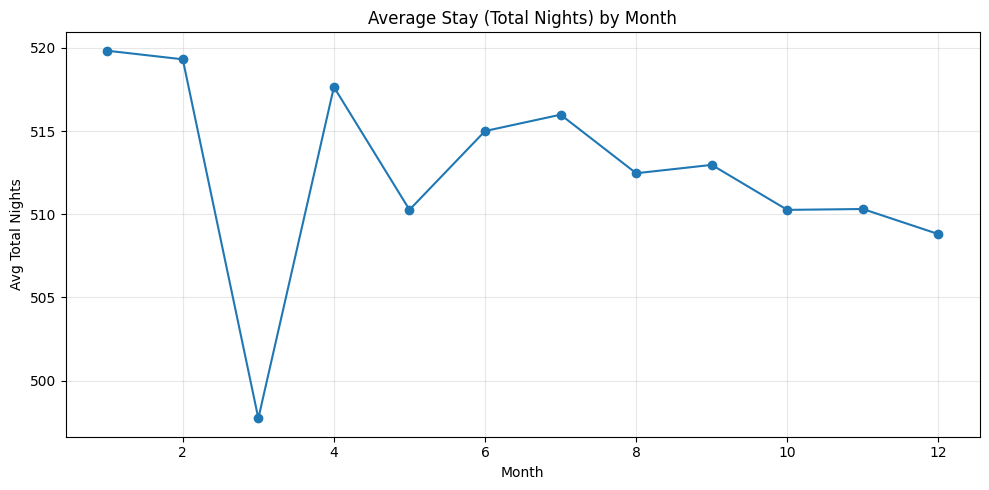

In [76]:
# Stay length by month
data['total_nights'] = data['total_nights'] + data['total_nights']

nights_trend = data.groupby('booking_month')['total_nights'].mean()

plt.figure(figsize=(10,5))
plt.plot(nights_trend.index, nights_trend.values, marker='o')

plt.title('Average Stay (Total Nights) by Month')
plt.xlabel('Month')
plt.ylabel('Avg Total Nights')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Average Stay by  Month.png', dpi=300, bbox_inches='tight')
plt.show()


In [51]:
cancel_trend = data.groupby('booking_month')['is_cancelled'].mean() * 100
cancel_trend

booking_month
1     30.762712
2     25.375235
3     24.491525
4     24.343569
5     25.550847
6     25.218914
7     37.314697
8     35.169492
9     26.182137
10    25.466102
11    23.719912
12    32.118644
Name: is_cancelled, dtype: float64

Insight :
Cancellations show a clear seasonal trend, peaking during high-demand months like July, August, and December. However, average stay duration remains consistent across months, indicating that cancellations are driven more by booking behavior and seasonality rather than how long customers plan to stay.